Upload Train.csv


Saving Train.csv to Train (1).csv

========== DATASET INFORMATION ==========
Rows    : 8068
Columns : 11

First 5 rows:
       ID  Gender Ever_Married  Age Graduated     Profession  Work_Experience  \
0  462809    Male           No   22        No     Healthcare              1.0   
1  462643  Female          Yes   38       Yes       Engineer              NaN   
2  466315  Female          Yes   67       Yes       Engineer              1.0   
3  461735    Male          Yes   67       Yes         Lawyer              0.0   
4  462669  Female          Yes   40       Yes  Entertainment              NaN   

  Spending_Score  Family_Size  Var_1 Segmentation  
0            Low          4.0  Cat_4            D  
1        Average          3.0  Cat_4            A  
2            Low          1.0  Cat_6            B  
3           High          2.0  Cat_6            B  
4           High          6.0  Cat_6            A  

========== DATA VALIDATION ==========

Column names:
['ID', 'Gender', 'Ever_Marr

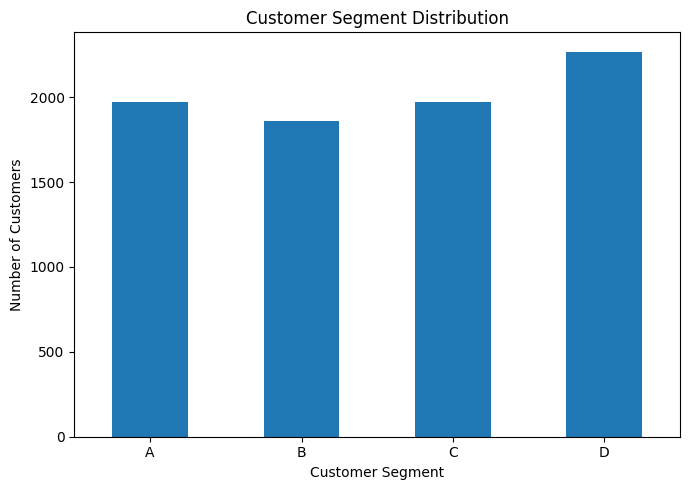


========== FEATURE GROUPS ==========
Demographic : ['Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Work_Experience', 'Family_Size']
Psychographic: ['Spending_Score']
Behavioral  : ['Var_1']
Combined    : ['Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Work_Experience', 'Family_Size', 'Spending_Score', 'Var_1']

========== DATA SPLIT ==========
Training rows : 6454
Testing rows  : 1614

Numerical columns:
['Age', 'Work_Experience', 'Family_Size']

Categorical columns:
['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1']

========== 5-FOLD CROSS VALIDATION ==========

MODEL RESULTS:
          Model  Accuracy  Macro F1  Macro F1 SD  Weighted F1
  CategoricalNB  0.509450  0.484523     0.009047     0.493837
    BernoulliNB  0.503099  0.480073     0.007801     0.489105
     GaussianNB  0.420205  0.371894     0.010619     0.382897
DummyClassifier  0.281066  0.109700     0.000068     0.123332


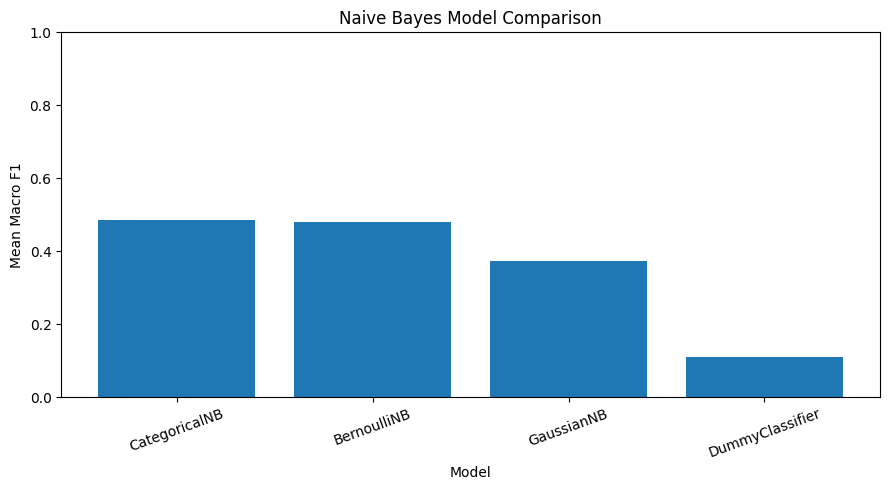


========== MODEL SELECTION ==========
Selected Model: CategoricalNB
Best Macro F1 : 0.4845234483606647
Macro F1 SD   : 0.009046976104154232

========== FINAL TEST RESULTS ==========
Accuracy: 0.5117719950433705
Macro F1: 0.48528393969993966
Weighted F1: 0.4954911555490408

Classification Report:
              precision    recall  f1-score   support

           A       0.43      0.40      0.41       394
           B       0.37      0.22      0.28       372
           C       0.50      0.65      0.57       394
           D       0.65      0.72      0.68       454

    accuracy                           0.51      1614
   macro avg       0.49      0.50      0.49      1614
weighted avg       0.49      0.51      0.50      1614



/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


<Figure size 700x600 with 0 Axes>

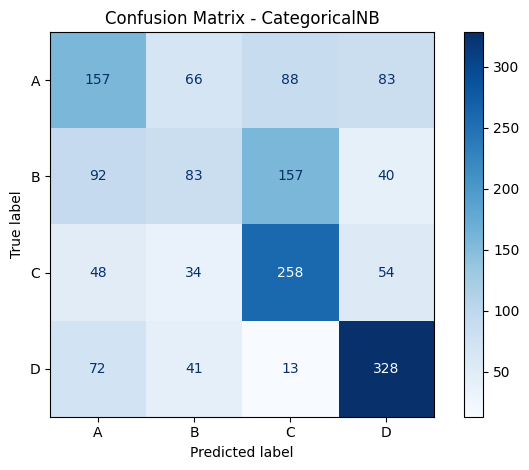


========== FEATURE GROUP COMPARISON ==========
Feature Group  Macro F1
  Demographic  0.483618
Psychographic  0.264858
   Behavioral  0.198471
     Combined  0.483633


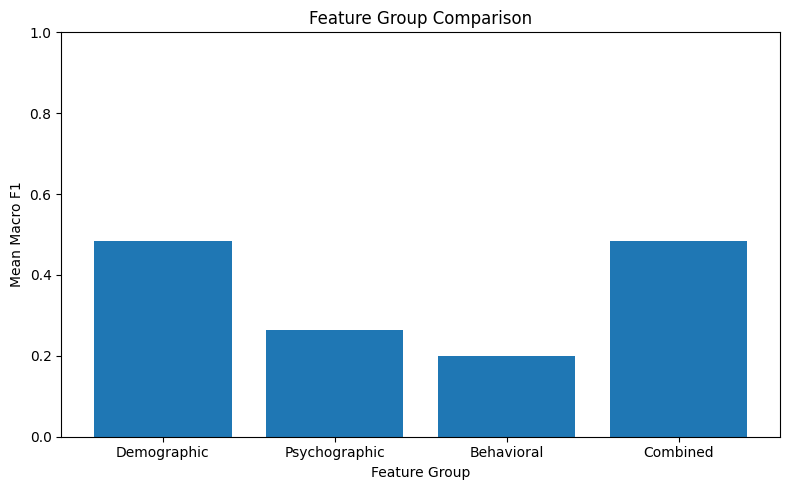


========== FIVE ERROR CASES ==========
      Gender Ever_Married  Age Graduated Profession  Work_Experience Spending_Score  Family_Size  Var_1 Actual Predicted
6302  Female          Yes   36       Yes     Doctor              0.0            Low          1.0  Cat_6      B         A
4585  Female          Yes   59        No     Artist              1.0            Low          3.0  Cat_4      C         A
5956    Male          Yes   39       Yes     Artist              3.0        Average          4.0  Cat_6      B         C
6557    Male          NaN   33        No  Marketing              1.0           High          1.0  Cat_6      D         A
3975  Female          Yes   52        No  Marketing              1.0           High          3.0  Cat_4      D         A

========== COMPLETED ==========


In [ ]:
 # ============================================================
# MDI3003 LAB 04 - CUSTOMER SEGMENT PREDICTION
# Dataset: Train.csv
# Based on the given PDF
# ============================================================

from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, KBinsDiscretizer
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB, CategoricalNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

# ------------------------------------------------------------
# 1. UPLOAD DATASET
# ------------------------------------------------------------

print("Upload Train.csv")
files.upload()

df = pd.read_csv("Train.csv")

print("\n========== DATASET INFORMATION ==========")
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

print("\nFirst 5 rows:")
print(df.head())

# ------------------------------------------------------------
# 2. DATA VALIDATION
# ------------------------------------------------------------

print("\n========== DATA VALIDATION ==========")

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate IDs :", df["ID"].duplicated().sum())

print("\nTarget distribution:")
print(df["Segmentation"].value_counts())

# ------------------------------------------------------------
# 3. TARGET DISTRIBUTION GRAPH
# ------------------------------------------------------------

plt.figure(figsize=(7,5))

df["Segmentation"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. REMOVE ID
# ------------------------------------------------------------

df = df.drop("ID", axis=1)

X = df.drop("Segmentation", axis=1)
y = df["Segmentation"]

# ------------------------------------------------------------
# 5. FEATURE GROUPS
# ------------------------------------------------------------

DEMOGRAPHIC = [
    "Gender",
    "Ever_Married",
    "Age",
    "Graduated",
    "Profession",
    "Work_Experience",
    "Family_Size"
]

PSYCHOGRAPHIC = [
    "Spending_Score"
]

BEHAVIORAL = [
    "Var_1"
]

# Keep only columns present in dataset
DEMOGRAPHIC = [c for c in DEMOGRAPHIC if c in X.columns]
PSYCHOGRAPHIC = [c for c in PSYCHOGRAPHIC if c in X.columns]
BEHAVIORAL = [c for c in BEHAVIORAL if c in X.columns]

ALL_FEATURES = list(dict.fromkeys(
    DEMOGRAPHIC + PSYCHOGRAPHIC + BEHAVIORAL
))

print("\n========== FEATURE GROUPS ==========")

print("Demographic :", DEMOGRAPHIC)
print("Psychographic:", PSYCHOGRAPHIC)
print("Behavioral  :", BEHAVIORAL)
print("Combined    :", ALL_FEATURES)

# ------------------------------------------------------------
# 6. TRAIN / TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n========== DATA SPLIT ==========")
print("Training rows :", len(X_train))
print("Testing rows  :", len(X_test))

# ------------------------------------------------------------
# 7. FIND NUMERICAL AND CATEGORICAL FEATURES
# ------------------------------------------------------------

numeric_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("\nNumerical columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

# ------------------------------------------------------------
# 8. PREPROCESSING FOR BERNOULLI NB
# ------------------------------------------------------------

numeric_bernoulli = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("bins", KBinsDiscretizer(
        n_bins=5,
        encode="onehot",
        strategy="quantile"
    ))
])

categorical_bernoulli = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

bernoulli_prep = ColumnTransformer([
    ("numeric", numeric_bernoulli, numeric_cols),
    ("categorical", categorical_bernoulli, categorical_cols)
])

# ------------------------------------------------------------
# 9. SAFE ENCODER FOR CATEGORICAL NB
# ------------------------------------------------------------

class SafeOrdinalEncoder:

    def __init__(self):
        self.encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )

    def fit(self, X, y=None):
        self.encoder.fit(X)
        return self

    def transform(self, X):
        return self.encoder.transform(X).astype(int) + 1

    def fit_transform(self, X, y=None):
        self.fit(X, y)
        return self.transform(X)

# ------------------------------------------------------------
# 10. PREPROCESSING FOR CATEGORICAL NB
# ------------------------------------------------------------

numeric_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("bins", KBinsDiscretizer(
        n_bins=5,
        encode="ordinal",
        strategy="quantile"
    ))
])

categorical_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", SafeOrdinalEncoder())
])

categorical_prep = ColumnTransformer([
    ("numeric", numeric_cat, numeric_cols),
    ("categorical", categorical_cat, categorical_cols)
])

# ------------------------------------------------------------
# 11. GAUSSIAN NB PREPROCESSING
# ------------------------------------------------------------

gaussian_prep = ColumnTransformer([
    ("numeric",
     SimpleImputer(strategy="median"),
     numeric_cols)
])

# ------------------------------------------------------------
# 12. FOUR CORE MODELS FROM PDF
# ------------------------------------------------------------

models = {

    "DummyClassifier": Pipeline([
        ("model",
         DummyClassifier(strategy="most_frequent"))
    ]),

    "GaussianNB": Pipeline([
        ("prep", gaussian_prep),
        ("model", GaussianNB())
    ]),

    "BernoulliNB": Pipeline([
        ("prep", bernoulli_prep),
        ("model", BernoulliNB(alpha=1.0))
    ]),

    "CategoricalNB": Pipeline([
        ("prep", categorical_prep),
        ("model", CategoricalNB(alpha=1.0))
    ])
}

# ------------------------------------------------------------
# 13. 5-FOLD CROSS VALIDATION
# ------------------------------------------------------------

print("\n========== 5-FOLD CROSS VALIDATION ==========")

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "macro_f1": "f1_macro",
            "weighted_f1": "f1_weighted"
        },
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Macro F1": scores["test_macro_f1"].mean(),
        "Macro F1 SD": scores["test_macro_f1"].std(),
        "Weighted F1": scores["test_weighted_f1"].mean()
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "Macro F1",
    ascending=False
)

print("\nMODEL RESULTS:")
print(results_df.to_string(index=False))

# ------------------------------------------------------------
# 14. MODEL COMPARISON GRAPH
# ------------------------------------------------------------

plt.figure(figsize=(9,5))

plt.bar(
    results_df["Model"],
    results_df["Macro F1"]
)

plt.title("Naive Bayes Model Comparison")
plt.xlabel("Model")
plt.ylabel("Mean Macro F1")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 15. SELECT BEST MODEL
# ------------------------------------------------------------

best_name = results_df.iloc[0]["Model"]
best_model = models[best_name]

print("\n========== MODEL SELECTION ==========")
print("Selected Model:", best_name)
print("Best Macro F1 :", results_df.iloc[0]["Macro F1"])
print("Macro F1 SD   :", results_df.iloc[0]["Macro F1 SD"])

# ------------------------------------------------------------
# 16. TRAIN BEST MODEL
# ------------------------------------------------------------

best_model.fit(
    X_train,
    y_train
)

y_pred = best_model.predict(
    X_test
)

# ------------------------------------------------------------
# 17. FINAL OUTPUT
# ------------------------------------------------------------

print("\n========== FINAL TEST RESULTS ==========")

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("Macro F1:",
      f1_score(y_test, y_pred, average="macro"))

print("Weighted F1:",
      f1_score(y_test, y_pred, average="weighted"))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

# ------------------------------------------------------------
# 18. CONFUSION MATRIX GRAPH
# ------------------------------------------------------------

plt.figure(figsize=(7,6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title(
    "Confusion Matrix - " + best_name
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 19. FEATURE GROUP COMPARISON
# ------------------------------------------------------------

print("\n========== FEATURE GROUP COMPARISON ==========")

feature_groups = {
    "Demographic": DEMOGRAPHIC,
    "Psychographic": PSYCHOGRAPHIC,
    "Behavioral": BEHAVIORAL,
    "Combined": ALL_FEATURES
}

group_results = []

for group_name, columns in feature_groups.items():

    if len(columns) == 0:
        continue

    X_group = df[columns]

    num_group = X_group.select_dtypes(
        include=["int64", "float64"]
    ).columns.tolist()

    cat_group = X_group.select_dtypes(
        include=["object", "category", "bool"]
    ).columns.tolist()

    num_pipe = Pipeline([
        ("imputer",
         SimpleImputer(strategy="median")),
        ("bins",
         KBinsDiscretizer(
             n_bins=5,
             encode="ordinal",
             strategy="quantile"
         ))
    ])

    cat_pipe = Pipeline([
        ("imputer",
         SimpleImputer(strategy="most_frequent")),
        ("encoder",
         SafeOrdinalEncoder())
    ])

    prep = ColumnTransformer([
        ("num", num_pipe, num_group),
        ("cat", cat_pipe, cat_group)
    ])

    pipe = Pipeline([
        ("prep", prep),
        ("model", CategoricalNB(alpha=1.0))
    ])

    scores = cross_validate(
        pipe,
        X_group,
        y,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )

    group_results.append({
        "Feature Group": group_name,
        "Macro F1": scores["test_score"].mean()
    })

group_df = pd.DataFrame(group_results)

print(group_df.to_string(index=False))

# ------------------------------------------------------------
# 20. FEATURE GROUP GRAPH
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

plt.bar(
    group_df["Feature Group"],
    group_df["Macro F1"]
)

plt.title("Feature Group Comparison")
plt.xlabel("Feature Group")
plt.ylabel("Mean Macro F1")
plt.ylim(0,1)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 21. SHOW FIVE PREDICTION ERRORS
# ------------------------------------------------------------

print("\n========== FIVE ERROR CASES ==========")

error_df = X_test.copy()

error_df["Actual"] = y_test
error_df["Predicted"] = y_pred

errors = error_df[
    error_df["Actual"] != error_df["Predicted"]
]

print(
    errors.head(5).to_string()
)

print("\n========== COMPLETED ==========")